<a href="https://colab.research.google.com/github/JKniaaa/SC3000-Artificial-Intelligence/blob/dev/Lab%201/cartpole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy==1.26.0
!pip install tensorflow==2.18.0


[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gym
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from gym.wrappers import RecordVideo
from IPython.display import HTML, display, Video
import time
import os
import glob
import base64
import io
import cv2
import math

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")

In [3]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [4]:
print(env.action_space)

Discrete(2)


In [5]:
print(env.observation_space)

Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)


In [6]:
observation = env.reset()
print("Initial observations: ", observation)

Initial observations:  [ 0.03448296  0.01022526 -0.0324913   0.02509105]


In [7]:
observation, reward, done, info = env.step(0)
print("New observations after choosing action 0:", observation)
print("Reward for this step:", reward)
print("Is this round done?", done)
print("Additional info:", info)

New observations after choosing action 0: [ 0.03468746 -0.18441604 -0.03198949  0.30734813]
Reward for this step: 1.0
Is this round done? False
Additional info: {}


c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\utils\passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


In [8]:
observation = env.reset()
cumulative_reward = 0
done = False
while not done:
    observation, reward, done, info = env.step(0)
    cumulative_reward += reward
print("Cumulative reward for this round:", cumulative_reward)

Cumulative reward for this round: 9.0


In [9]:
observation = env.reset()

frames = []

# Capture 100 frames
for _ in range(100):
    frame = env.render()
    frame = np.array(frame).astype(np.uint8)

    # Remove batch dimension if present
    if frame.shape[0] == 1:
        frame = frame.squeeze(axis=0)  # Removes the extra dimension

    # Debugging: Print corrected frame shape
    # print("Corrected Frame shape:", frame.shape)

    # Ensure frame is RGB
    if len(frame.shape) == 2:  # If grayscale
        frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
    elif len(frame.shape) == 3 and frame.shape[2] == 1:  # If single-channel
        frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)

    frames.append(frame)

    action = env.action_space.sample()
    observation, reward, terminated, info = env.step(action)
    if terminated:
        observation = env.reset()

env.close()

# Check frame shape before saving
if len(frames) == 0:
    raise ValueError("No frames were captured. Ensure env.render() is working.")

# Save frames as an AVI file
def create_avi_video(frames, video_name='cartpole.avi', fps=20):
    height, width = frames[0].shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'MJPG')
    video = cv2.VideoWriter(video_name, fourcc, fps, (width, height))

    for frame in frames:
        video.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

    video.release()

# Convert AVI to MP4 using ffmpeg (to ensure browser compatibility)
def convert_to_mp4(input_file='cartpole.avi', output_file='cartpole.mp4'):
    os.system(f"ffmpeg -i {input_file} -vcodec libx264 {output_file} -y")

# Generate AVI and convert to MP4
create_avi_video(frames, 'cartpole.avi')
convert_to_mp4('cartpole.avi', 'cartpole.mp4')

# Display the MP4 video
display(Video('cartpole.mp4', embed=True))

# Task 1

In [10]:
def rand_policy_agent(observation):
    return random.randint(0, 1)

In [11]:
observation = env.reset()
action = rand_policy_agent(observation)
print("Observation:", observation)
print("Chosen action:", action)

Observation: [-0.02256783 -0.00541135 -0.04332331 -0.02967484]
Chosen action: 1


# Task 2

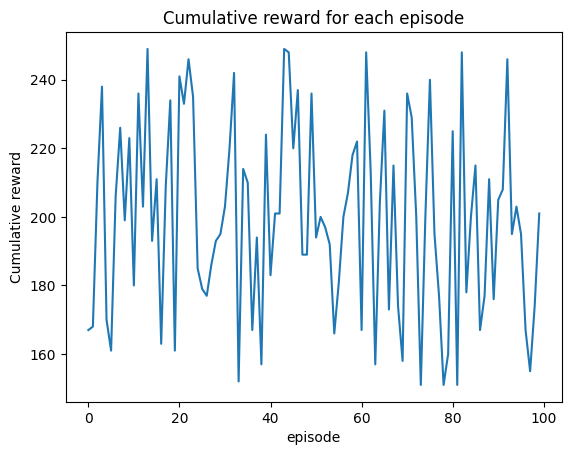

In [12]:
episode_results = np.random.randint(150, 250, size=100)
plt.plot(episode_results)
plt.title('Cumulative reward for each episode')
plt.ylabel('Cumulative reward')
plt.xlabel('episode')
plt.show()

In [13]:
print("Average cumulative reward:", episode_results.mean())
print("Is my agent good enough?", episode_results.mean() > 195)

Average cumulative reward: 199.66
Is my agent good enough? True


# Task 3

In [14]:
env = RecordVideo(gym.make("CartPole-v1"), "./video")
observation = env.reset()
while True:
    env.render()
    #your agent goes here
    action = rand_policy_agent(observation)
    observation, reward, done, info = env.step(action)
    if done:
      break
env.close()
show_video()

c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\wrappers\record_video.py:78: UserWarning: WARN: Overwriting existing videos at c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\Lab 1\video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\wrappers\monitoring\video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment CartPole-v1 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  depr